# Data and the $\Lambda$CDM prediction (thesis figures)

For each likelihood this notebook plots **the data with their error bars** and, on top, the
**$\Lambda$CDM prediction**: the best-fit curve and the 68 % / 95 % confidence tube obtained by
propagating the chain of

$$\textrm{CC}_{\rm cov} \;+\; \textrm{Pantheon+ (no SH0ES)} \;+\; \textrm{QSO} \;+\; \textrm{DESI DR2},$$

that is, `fR-MCMC_test_runs/LCDM_CCcov+PPlus+QSO+DESI_DE/chain.h5` (see `run_test_ext.py`).

Datasets: **CC with covariance, CC legacy, Pantheon, Pantheon+, QSO, AGN, DESI DR2, BAO legacy 2
and BAO legacy 1.** Only CC$_{\rm cov}$, Pantheon+, QSO and DESI DR2 enter that chain; the rest
are shown against the same prediction to check consistency.

Figures are written to `notebooks/output/plot_data_thesis/` as PDF (vector, for LaTeX). They carry
no title: the file name identifies each one and the caption belongs in the thesis.

> Environment: `conda activate obs-cosmo` (needs `emcee`, `numba`, `git` and the $r_d$ grid in
> `fr_mcmc/source/rd_grid/`).

In [1]:
import os
import sys
import numpy as np
import emcee
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

import git
path_git = git.Repo('.', search_parent_directories=True).working_tree_dir
path_global = os.path.dirname(path_git)
os.chdir(path_git)
sys.path.append(os.path.join(path_git, 'fr_mcmc', 'utils'))

from LambdaCDM import H_LCDM
from supernovae import aparent_magnitude_th
from BAO import Hs_to_Ds, Ds_to_obs_final, r_drag_grid
from AGN import zs_2_logDlH0
from constants import WB_BBN
from data import (read_data_pantheon, read_data_pantheon_plus, read_data_BAO,
                  read_data_BAO_full, read_data_chronometers, read_data_DESI, read_data_AGN)
from CC_cov import read_data_CC_cov
from QSO import read_data_QSO

SOURCE = os.path.join(path_git, 'fr_mcmc', 'source')
OUT = os.path.join(path_git, 'notebooks', 'output', 'plot_data_thesis')
os.makedirs(OUT, exist_ok=True)
print(OUT)

/home/matias/Documents/PhD/code/fR-MCMC/notebooks/output/plot_data_thesis


## Style

One colour for the model (blue), neutral ink for the data, and a second or third colour only
where two or three families of points share a panel.

In [2]:
INK, INK2, GRID = '#0b0b0b', '#52514e', '#d8d7d2'   # primary / secondary ink, grid
MODEL, ALT, ALT2 = '#2a78d6', '#eb6834', '#1baf7a'  # model, and 2nd / 3rd data series

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.labelsize': 11,
    'axes.edgecolor': INK2, 'axes.linewidth': 0.8, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'grid.alpha': 0.8,
    'xtick.color': INK2, 'ytick.color': INK2,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'legend.frameon': False, 'legend.fontsize': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': INK, 'axes.labelcolor': INK,
    'lines.linewidth': 2.0, 'errorbar.capsize': 0,
})


def plot_data(ax, z, y, e, label, color=INK, ms=4.5, alpha=1.0, elw=1.1):
    '''Points with error bars.'''
    return ax.errorbar(z, y, e, fmt='o', ms=ms, mfc=color, mec='white', mew=0.5,
                       ecolor=color, elinewidth=elw, alpha=alpha, ls='none',
                       label=label, zorder=3)


def plot_band(ax, z, best, q, label_line, label_band='68 % / 95 % from the chain', color=MODEL):
    '''Confidence tube (95 % and 68 %) plus the best-fit curve.'''
    ax.fill_between(z, q[0], q[3], color=color, alpha=0.16, lw=0, zorder=1)
    ax.fill_between(z, q[1], q[2], color=color, alpha=0.34, lw=0, zorder=1,
                    label=label_band)
    ax.plot(z, best, color=color, lw=2.0, zorder=2, label=label_line)


def legend_below(fig, axes, ncol=3):
    '''A single legend below the figure, so it never covers the data.'''
    handles, labels = [], []
    for ax in np.atleast_1d(axes).ravel():
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02),
               ncol=ncol, handletextpad=0.6, columnspacing=1.6)


def sym_lim(res, p=99.0):
    '''Robust symmetric limits for the residual panels.'''
    m = np.percentile(np.abs(res), p)
    return -1.15 * m, 1.15 * m

## Data

Everything is read with the same functions the likelihoods use, so what is plotted is what
enters the $\chi^2$.

In [3]:
os.chdir(os.path.join(SOURCE, 'CC_cov'))
ds_CC_cov = read_data_CC_cov('../CC/chronometers_data.txt', 'HzTable_MM_BC03.dat', 'data_MM20.dat')

os.chdir(os.path.join(SOURCE, 'CC_legacy'))
ds_CC_legacy = read_data_chronometers('chronometers_data.txt')

os.chdir(os.path.join(SOURCE, 'Pantheon'))
ds_SN = read_data_pantheon('lcparam_full_long_zhel.txt')

os.chdir(os.path.join(SOURCE, 'Pantheon_plus_shoes'))
ds_PP = read_data_pantheon_plus('Pantheon+SH0ES.dat', 'Pantheon+SH0ES_STAT+SYS.cov')

os.chdir(os.path.join(SOURCE, 'QSO'))
ds_QSO = read_data_QSO('qso_benetti2025.txt')

os.chdir(os.path.join(SOURCE, 'AGN'))
ds_AGN = read_data_AGN('table3.dat')

os.chdir(os.path.join(SOURCE, 'DESI'))
ds_DESI = read_data_DESI('DESI_DR2_dm_dh.txt', 'DESI_DR2_dv.txt')

os.chdir(os.path.join(SOURCE, 'BAO_legacy_2'))
ds_BAO_full = read_data_BAO_full('BAO_full_1.csv', 'BAO_full_2.csv')

os.chdir(os.path.join(SOURCE, 'BAO_legacy_1'))
# np.atleast_1d: BAO_data_da.txt has a single row and loadtxt returns scalars.
# The order matters: indices 0..4 are Da, Dh, Dm, Dv, H (see BAO.Hs_to_Ds).
ds_BAO = [tuple(np.atleast_1d(a) for a in read_data_BAO(f))
          for f in ['BAO_data_da.txt', 'BAO_data_dh.txt', 'BAO_data_dm.txt',
                    'BAO_data_dv.txt', 'BAO_data_H.txt']]

os.chdir(path_git)

print('CC_cov      N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_CC_cov[0]), ds_CC_cov[0].min(), ds_CC_cov[0].max()))
print('CC_legacy   N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_CC_legacy[0]), ds_CC_legacy[0].min(), ds_CC_legacy[0].max()))
print('Pantheon    N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_SN[0]), ds_SN[0].min(), ds_SN[0].max()))
print('Pantheon+   N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_PP[0]), ds_PP[0].min(), ds_PP[0].max()))
print('QSO         N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_QSO[0]), ds_QSO[0].min(), ds_QSO[0].max()))
print('AGN         N = {:5d}   z = [{:.3f}, {:.3f}]'.format(len(ds_AGN[0]), ds_AGN[0].min(), ds_AGN[0].max()))
print('DESI DR2    N = {:5d}   ({} Dm-Dh pairs + {} Dv)'.format(2*len(ds_DESI[0][0]) + len(ds_DESI[1][0]),
                                                               len(ds_DESI[0][0]), len(ds_DESI[1][0])))
print('BAO_legacy_2 N = {:4d}   ({} uncorrelated + {} Dm-Dh pairs)'.format(
    len(ds_BAO_full[0][0]) + 2*len(ds_BAO_full[1][0]), len(ds_BAO_full[0][0]), len(ds_BAO_full[1][0])))
print('BAO_legacy_1 N = {:4d}   ({})'.format(sum(len(d[0]) for d in ds_BAO),
                                             ', '.join('{} {}'.format(len(d[0]), n) for d, n in
                                                       zip(ds_BAO, ['Da', 'Dh', 'Dm', 'Dv', 'H*rd']))))

CC_cov      N =    33   z = [0.070, 1.965]
CC_legacy   N =    30   z = [0.070, 1.965]
Pantheon    N =  1048   z = [0.010, 2.260]
Pantheon+   N =  1590   z = [0.010, 2.261]
QSO         N =  2014   z = [0.009, 7.541]
AGN         N =  2421   z = [0.009, 7.541]
DESI DR2    N =    13   (6 Dm-Dh pairs + 1 Dv)
BAO_legacy_2 N =   15   (7 uncorrelated + 4 Dm-Dh pairs)
BAO_legacy_1 N =   20   (1 Da, 4 Dh, 7 Dm, 5 Dv, 3 H*rd)


## The chain: best fit and confidence tube

The first 20 % is discarded (the same burn-in `run_test_ext.py` uses for its `summary.json`).
The **best fit** is the maximum-posterior point of the chain, and the tube comes from propagating
`N_BAND` random posterior samples and taking the 2.5/16/84/97.5 percentiles at each $z$.

$r_d$ is interpolated from the CLASS grid (`BAO.r_drag_grid`, validated in `check_rd_grid.ipynb`),
which agrees with `r_drag_class` — the one used in the run — to better than $10^{-6}$.

In [4]:
CHAIN = os.path.join(path_global, 'fR-MCMC_test_runs', 'LCDM_CCcov+PPlus+QSO+DESI_DE', 'chain.h5')
N_BAND = 400        # posterior samples forming the tube
SEED = 42

reader = emcee.backends.HDFBackend(CHAIN, read_only=True)
burnin = int(0.2 * reader.iteration)
flat = reader.get_chain(discard=burnin, flat=True)       # columns: M, Omega_m, H0
log_prob = reader.get_log_prob(discard=burnin, flat=True)
theta_bf = flat[np.argmax(log_prob)]

rng = np.random.default_rng(SEED)
sub = flat[rng.choice(len(flat), N_BAND, replace=False)]

names = ['M', 'Omega_m', 'H0']
print('chain: {}  ({} iterations, burn-in {}, {} flat samples)'.format(
    os.path.relpath(CHAIN, path_global), reader.iteration, burnin, len(flat)))
for i, n in enumerate(names):
    print('  {:8s} best fit = {:10.4f}   mean = {:10.4f} +- {:.4f}'.format(
        n, theta_bf[i], flat[:, i].mean(), flat[:, i].std()))

chain: fR-MCMC_test_runs/LCDM_CCcov+PPlus+QSO+DESI_DE/chain.h5  (1600 iterations, burn-in 320, 40960 flat samples)
  M        best fit =   -19.3979   mean =   -19.3969 +- 0.0133
  Omega_m  best fit =     0.3126   mean =     0.3131 +- 0.0074
  H0       best fit =    68.7088   mean =    68.7360 +- 0.3811


In [5]:
class Model:
    '''LCDM H(z) and the derived quantities the likelihoods need.'''

    def __init__(self, theta, z_max=10.0, num_z_points=int(1e5)):
        self.M, self.omega_m, self.H0 = theta
        zs = np.linspace(0, z_max, num_z_points)
        Hs = H_LCDM(zs, self.omega_m, self.H0)
        self.H = interp1d(zs, Hs)                                                  # H(z)
        self.int_inv_H = interp1d(zs, cumulative_trapezoid(1 / Hs, zs, initial=0))  # int dz/H
        self._rd = None

    @property
    def rd(self):
        if self._rd is None:
            self._rd = r_drag_grid(self.omega_m, self.H0, WB_BBN)
        return self._rd

    def bao(self, z, index):
        '''index: 0 = D_A/rd, 1 = D_H/rd, 2 = D_M/rd, 3 = D_V/rd, 4 = H*rd.'''
        return Ds_to_obs_final(Hs_to_Ds(self.H, self.int_inv_H, z, index), self.rd, index)


model_bf = Model(theta_bf)
models_band = [Model(t) for t in sub]


def tube(f, zgrid):
    '''f(Model, z) -> array. Returns (best-fit curve, percentiles 2.5/16/84/97.5).'''
    curves = np.array([f(m, zgrid) for m in models_band])
    return f(model_bf, zgrid), np.percentile(curves, [2.5, 16, 84, 97.5], axis=0)


LAB_BF = r'$\Lambda$CDM best fit ($\Omega_m = {:.3f}$, $H_0 = {:.1f}$)'.format(theta_bf[1], theta_bf[2])
print('r_d(best fit) = {:.2f} Mpc'.format(model_bf.rd))

r_d(best fit) = 146.08 Mpc


## 1. Cosmic chronometers with covariance (`CC_cov`)

The 33 $H(z)$ points of `CC/chronometers_data.txt`. The 15 Moresco BC03 measurements carry the
covariance of Moresco et al. (2020); the other 18 stay diagonal. Error bars are
$\sqrt{\mathrm{diag}\,C}$, so they do **not** show the correlation among the Moresco points.

Both groups come from Table 1 of Moresco (2023), [arXiv:2307.09501](https://arxiv.org/abs/2307.09501),
matched one to one: the 15 with covariance are Moresco+12 (8), Moresco+16 (5) and Moresco+15 (2),
all measured with the D4000 method; the 18 diagonal ones are Simon+05 (9), Zhang+14 (4),
Stern+10 (2), Ratsimbazafy+17, Jimenez+23 and Tomasetti+23. The covariance is defined **only**
for the Moresco sample: the files at https://gitlab.com/mmoresco/CCcovariance
(`HzTable_MM_BC03.dat`, `data_MM20.dat`) cover those 15 points, and the README asks to cite
Moresco et al. 2012, 2015 and 2016.

`CC_cov.py` builds $C = \mathrm{diag}(\sigma^2) + C_{\rm IMF} + C_{\rm SPS}$ exactly as the
`CC_fit.ipynb` of that repository, and reproduces its published CC-only result on those 15
points: $H_0 = 66.1^{+3.9}_{-4.0}$ without systematics and $65.9 \pm 5.6$ with the full
covariance, against $66.2^{+3.8}_{-3.9}$ and $66^{+5.5}_{-5.6}$ in Moresco.

> **33 points since 2026-09-22.** Table 1 of Moresco (2023) has 35 rows and the repository had
> 30; Ratsimbazafy+17 ($z = 0.47$), Tomasetti+23 ($z = 1.26$) and Jimenez+23 ($z = 0.75$, ML)
> were added. The other two, Borghi+22 ($z = 0.75$, Lick) and Jiao+23 ($z = 0.8$, full-spectrum),
> come from the **same sample** as Jimenez+23 and the paper warns they must not be used together,
> so the most precise one was kept. The usable maximum is therefore 33, not 35, and the three new
> points stay diagonal. Full detail in `fr_mcmc/source/CC/README.md`.

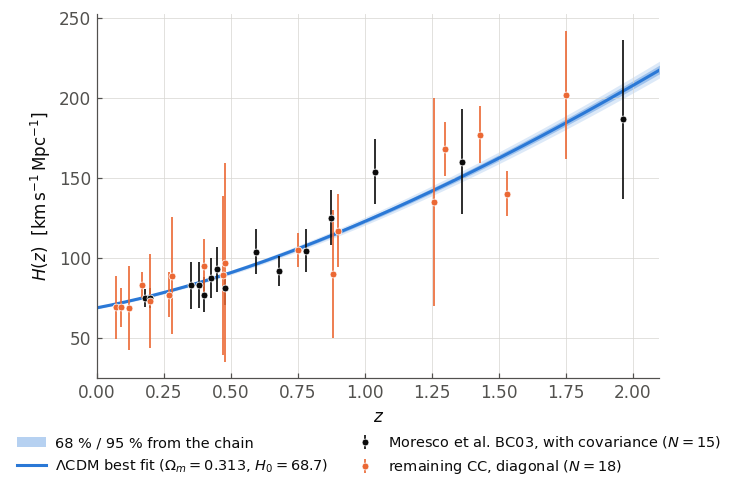

In [6]:
z_cc, H_cc, Cinv_cc, is_MM = ds_CC_cov
e_cc = np.sqrt(np.diag(np.linalg.inv(Cinv_cc)))

zgrid = np.linspace(0, 2.1, 400)
best, q = tube(lambda m, z: m.H(z), zgrid)

fig, ax = plt.subplots(figsize=(6.6, 4.3))
plot_band(ax, zgrid, best, q, LAB_BF)
plot_data(ax, z_cc[is_MM], H_cc[is_MM], e_cc[is_MM],
          'Moresco et al. BC03, with covariance ($N = {}$)'.format(is_MM.sum()), INK)
plot_data(ax, z_cc[~is_MM], H_cc[~is_MM], e_cc[~is_MM],
          'remaining CC, diagonal ($N = {}$)'.format((~is_MM).sum()), ALT)
ax.set_xlabel('$z$')
ax.set_ylabel(r'$H(z)\ \ [\rm km\,s^{-1}\,Mpc^{-1}]$')
ax.set_xlim(0, 2.1)
legend_below(fig, ax, ncol=2)
fig.savefig(os.path.join(OUT, 'CC_cov.pdf'))
plt.show()

## 2. Cosmic chronometers, legacy version (`CC_legacy`)

The **30** points of the 2022 paper ([arXiv:2112.01492](https://arxiv.org/abs/2112.01492)), with
their published errors and **no covariance**: this is what `dataset_CC` reads (`USE_CC` in the
config files). They are the ones of section 1 minus the three added from the Moresco (2023)
compilation, but with the values and errors exactly as the original papers published them,
without the systematic budget.

The grey bar behind each point is the error those same points carry in `CC_cov`: wherever grey
shows, the covariance widens the error bar.

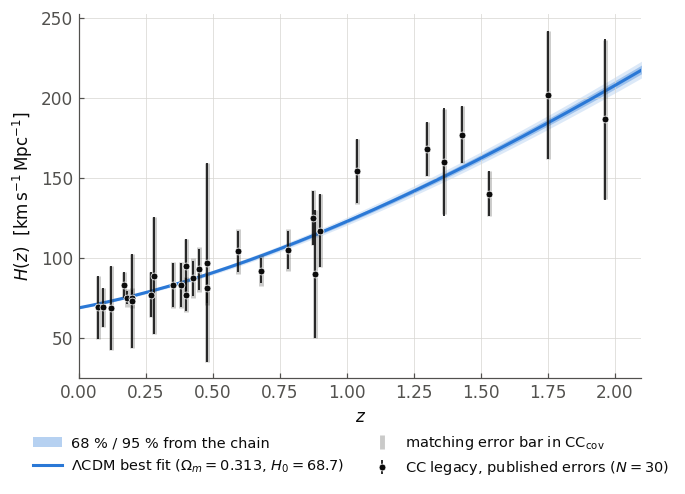

In [7]:
z_leg, H_leg, e_leg = ds_CC_legacy
order = np.argsort(z_leg)
z_leg, H_leg, e_leg = z_leg[order], H_leg[order], e_leg[order]

# matching error bar in CC_cov, at the same redshifts
e_cov_at_leg = np.array([e_cc[np.argmin(np.abs(z_cc - zz))] for zz in z_leg])

zgrid = np.linspace(0, 2.1, 400)
best, q = tube(lambda m, z: m.H(z), zgrid)

fig, ax = plt.subplots(figsize=(6.6, 4.3))
plot_band(ax, zgrid, best, q, LAB_BF)
ax.errorbar(z_leg, H_leg, e_cov_at_leg, fmt='none', ecolor=INK2, elinewidth=3.2, alpha=0.30,
            zorder=2, label=r'matching error bar in CC$_{\rm cov}$')
plot_data(ax, z_leg, H_leg, e_leg, 'CC legacy, published errors ($N = {}$)'.format(len(z_leg)), INK)
ax.set_xlabel('$z$')
ax.set_ylabel(r'$H(z)\ \ [\rm km\,s^{-1}\,Mpc^{-1}]$')
ax.set_xlim(0, 2.1)
legend_below(fig, ax, ncol=2)
fig.savefig(os.path.join(OUT, 'CC_legacy.pdf'))
plt.show()

## 3 and 4. Supernovae: Pantheon and Pantheon+

Hubble diagram in apparent magnitude $m_B$ (the raw datum) against
$m_B^{\rm th} = \mu(z) + M$, so the tube also carries the uncertainty on $M$. Below each one,
the residuals with respect to the best fit.

$M$ comes from the chain, which fits it with **Pantheon+ without SH0ES**; on Pantheon (2018) it
leaves a mean offset of only $\sim 0.02$ mag, so the two calibrations agree at the level of
the plot.

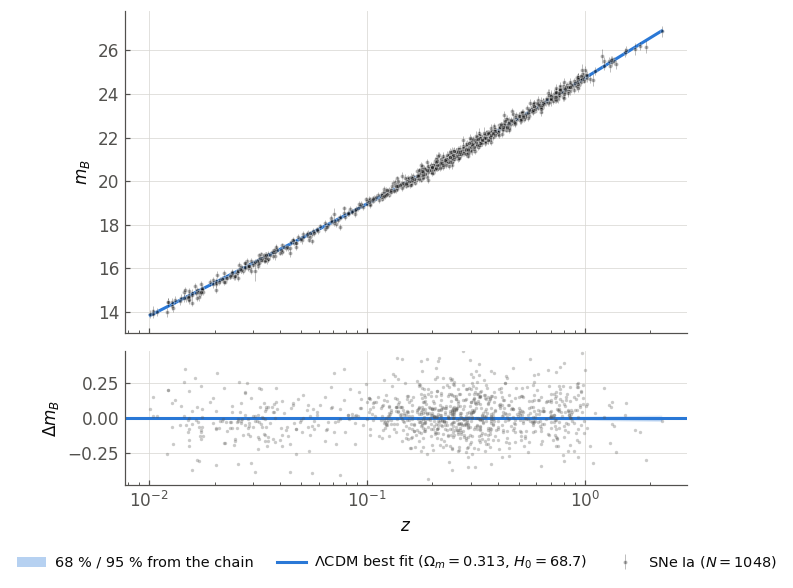

In [8]:
def figure_SN(dataset, filename):
    zcmb, zhel, Cinv, mb = (np.asarray(a) for a in dataset)
    e_mb = np.sqrt(np.diag(np.linalg.inv(Cinv)))

    zgrid = np.geomspace(zcmb.min(), zcmb.max(), 400)
    f = lambda m, z: aparent_magnitude_th(m.int_inv_H, z, z) + m.M
    best, q = tube(f, zgrid)
    mb_bf = aparent_magnitude_th(model_bf.int_inv_H, zcmb, zhel) + model_bf.M
    res = mb - mb_bf

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.6, 5.6), sharex=True,
                                 gridspec_kw=dict(height_ratios=[3, 1.25], hspace=0.08))
    plot_band(a1, zgrid, best, q, LAB_BF)
    plot_data(a1, zcmb, mb, e_mb, 'SNe Ia ($N = {}$)'.format(len(zcmb)),
              INK, ms=2.6, alpha=0.35, elw=0.5)
    a1.set_ylabel('$m_B$')
    a1.set_xscale('log')

    a2.fill_between(zgrid, q[0] - best, q[3] - best, color=MODEL, alpha=0.16, lw=0, zorder=1)
    a2.fill_between(zgrid, q[1] - best, q[2] - best, color=MODEL, alpha=0.34, lw=0, zorder=1)
    a2.axhline(0, color=MODEL, lw=2.0, zorder=2)
    a2.plot(zcmb, res, 'o', ms=2.2, color=INK2, alpha=0.30, mec='none', zorder=3)
    a2.set_xlabel('$z$')
    a2.set_ylabel(r'$\Delta m_B$')
    a2.set_ylim(*sym_lim(res))

    legend_below(fig, a1, ncol=3)
    fig.savefig(os.path.join(OUT, filename))
    plt.show()


figure_SN(ds_SN, 'Pantheon.pdf')

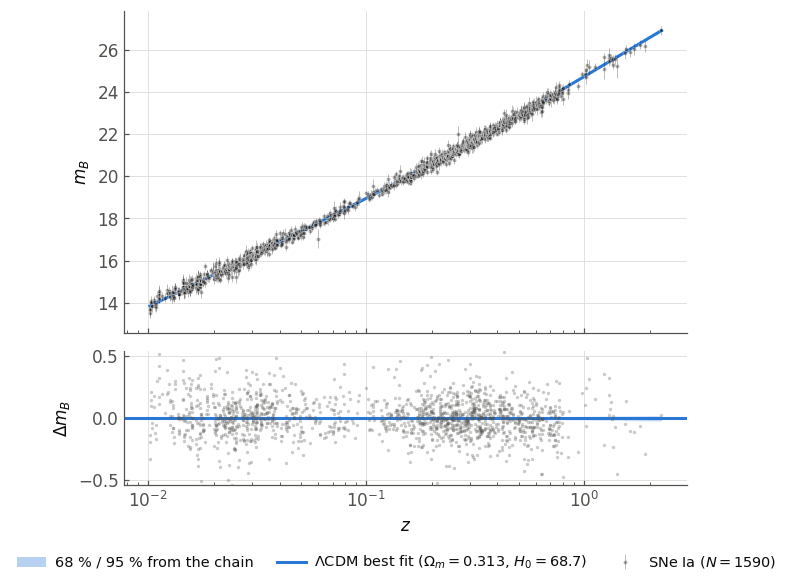

In [9]:
figure_SN(ds_PP, 'Pantheon_plus.pdf')

## 5. Quasars (QSO, Benetti et al. 2025)

Distance moduli of 2014 quasars obtained from the $L_X$–$L_{UV}$ relation with $\gamma$ and
$\beta$ held fixed. The model is $\mu^{\rm th}(z) + k$, with $k$ a calibration offset: the
likelihood marginalises it analytically, so here each chain sample uses its optimal value
$k = \sum w\,\delta / \sum w$, with $\delta = \mu^{\rm obs} - \mu^{\rm th}$ and
$w = \sigma_\mu^{-2}$. The tube therefore reflects only the **shape** of $H(z)/H_0$ — quasars do
not measure $H_0$.

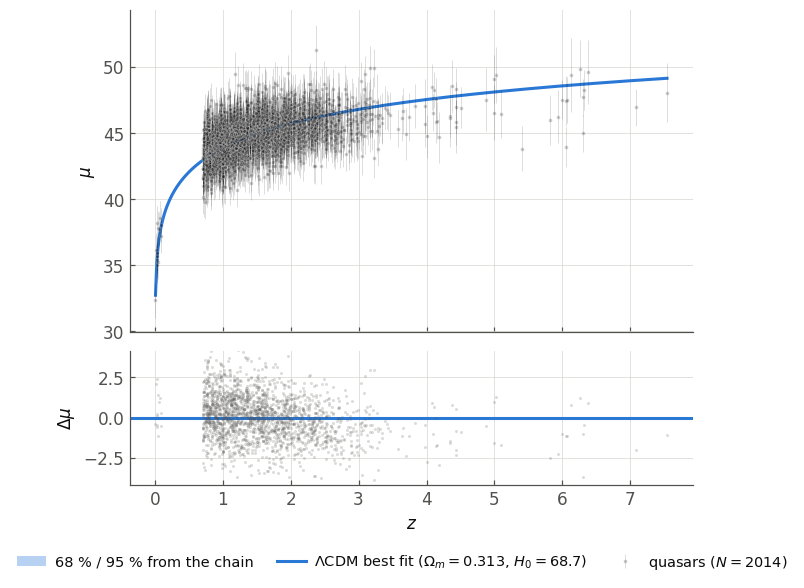

best-fit k = -0.2575 mag   (spread over the chain: 0.0178)


In [10]:
z_q, mu_q, e_q = ds_QSO
w_q = e_q ** (-2)


def k_marginalised(m):
    return np.sum((mu_q - aparent_magnitude_th(m.int_inv_H, z_q, z_q)) * w_q) / np.sum(w_q)


zgrid = np.linspace(z_q.min(), z_q.max(), 400)
best, q = tube(lambda m, z: aparent_magnitude_th(m.int_inv_H, z, z) + k_marginalised(m), zgrid)
mu_bf = aparent_magnitude_th(model_bf.int_inv_H, z_q, z_q) + k_marginalised(model_bf)
res = mu_q - mu_bf

fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.6, 5.6), sharex=True,
                             gridspec_kw=dict(height_ratios=[3, 1.25], hspace=0.08))
plot_band(a1, zgrid, best, q, LAB_BF)
plot_data(a1, z_q, mu_q, e_q, 'quasars ($N = {}$)'.format(len(z_q)),
          INK, ms=2.4, alpha=0.22, elw=0.4)
a1.set_ylabel(r'$\mu$')

a2.fill_between(zgrid, q[0] - best, q[3] - best, color=MODEL, alpha=0.16, lw=0, zorder=1)
a2.fill_between(zgrid, q[1] - best, q[2] - best, color=MODEL, alpha=0.34, lw=0, zorder=1)
a2.axhline(0, color=MODEL, lw=2.0, zorder=2)
a2.plot(z_q, res, 'o', ms=2.0, color=INK2, alpha=0.20, mec='none', zorder=3)
a2.set_xlabel('$z$')
a2.set_ylabel(r'$\Delta\mu$')
a2.set_ylim(*sym_lim(res))

legend_below(fig, a1, ncol=3)
fig.savefig(os.path.join(OUT, 'QSO.pdf'))
plt.show()

print('best-fit k = {:.4f} mag   (spread over the chain: {:.4f})'.format(
    k_marginalised(model_bf), np.std([k_marginalised(m) for m in models_band])))

## 6. AGN (Lusso et al. 2020)

The same X-ray and UV sample, in the form `chi_square.py` uses it: the observable is
$\log_{10}(D_L H_0)$, built from the fluxes with $\gamma = 0.648$ and $\beta = 7.735$ held
**fixed**, and its error propagates $\sigma_{F_X}$, $\sigma_{F_{UV}}$, $\sigma_\beta$ and
$\sigma_\gamma$.

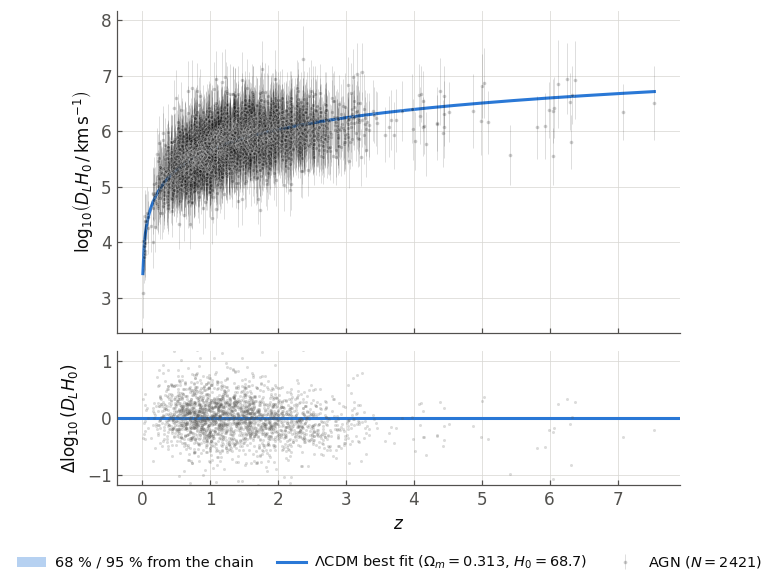

In [11]:
z_a, logFuv, eFuv, logFx, eFx = ds_AGN

beta, ebeta, gamma, egamma = 7.735, 0.244, 0.648, 0.007   # standard case of chi_square.py
y_a = np.log10(3.24) - 25 + (logFx - gamma * logFuv - beta) / (2 * gamma - 2)
df_dgamma = (-logFx + beta + logFuv) / (2 * (gamma - 1) ** 2)
e_a = np.sqrt((eFx ** 2 + gamma ** 2 * eFuv ** 2 + ebeta ** 2) / (2 * gamma - 2) ** 2
              + df_dgamma ** 2 * egamma ** 2)

zgrid = np.linspace(z_a.min(), z_a.max(), 400)
best, q = tube(lambda m, z: zs_2_logDlH0(m.int_inv_H(z) * m.H0, z), zgrid)
y_bf = zs_2_logDlH0(model_bf.int_inv_H(z_a) * model_bf.H0, z_a)
res = y_a - y_bf

fig, (a1, a2) = plt.subplots(2, 1, figsize=(6.6, 5.6), sharex=True,
                             gridspec_kw=dict(height_ratios=[3, 1.25], hspace=0.08))
plot_band(a1, zgrid, best, q, LAB_BF)
plot_data(a1, z_a, y_a, e_a, 'AGN ($N = {}$)'.format(len(z_a)),
          INK, ms=2.4, alpha=0.22, elw=0.4)
a1.set_ylabel(r'$\log_{10}\!\left(D_L H_0\,/\,\rm km\,s^{-1}\right)$')

a2.fill_between(zgrid, q[0] - best, q[3] - best, color=MODEL, alpha=0.16, lw=0, zorder=1)
a2.fill_between(zgrid, q[1] - best, q[2] - best, color=MODEL, alpha=0.34, lw=0, zorder=1)
a2.axhline(0, color=MODEL, lw=2.0, zorder=2)
a2.plot(z_a, res, 'o', ms=2.0, color=INK2, alpha=0.20, mec='none', zorder=3)
a2.set_xlabel('$z$')
a2.set_ylabel(r'$\Delta\log_{10}(D_L H_0)$')
a2.set_ylim(*sym_lim(res))

legend_below(fig, a1, ncol=3)
fig.savefig(os.path.join(OUT, 'AGN.pdf'))
plt.show()

## 7. DESI DR2

Six correlated $(D_M/r_d,\,D_H/r_d)$ measurements plus one $D_V/r_d$ at $z_{\rm eff} = 0.295$.
The bars are the marginal errors of each observable; the $\rho$ correlation between $D_M$ and
$D_H$, which does enter the $\chi^2$, is not visible in the plot.

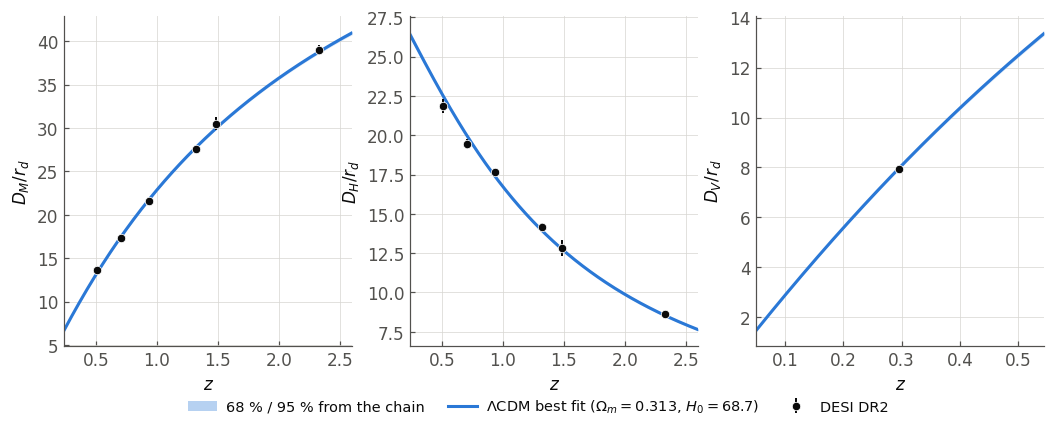

In [12]:
(desi_1, desi_2) = ds_DESI
z_dmdh, dm_rd, edm_rd, dh_rd, edh_rd, rho = (np.atleast_1d(a) for a in desi_1)
z_dv, dv_rd, edv_rd = (np.atleast_1d(a) for a in desi_2)

panels = [(2, r'$D_M/r_d$', z_dmdh, dm_rd, edm_rd),
          (1, r'$D_H/r_d$', z_dmdh, dh_rd, edh_rd),
          (3, r'$D_V/r_d$', z_dv, dv_rd, edv_rd)]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9))
for ax, (index, ylab, zd, yd, ed) in zip(axes, panels):
    pad = max(0.15 * (zd.max() - zd.min()), 0.25)   # only the z range covered by data
    zgrid = np.linspace(max(zd.min() - pad, 0.05), zd.max() + pad, 300)
    best, q = tube(lambda m, z, i=index: m.bao(z, i), zgrid)
    plot_band(ax, zgrid, best, q, LAB_BF)
    plot_data(ax, zd, yd, ed, 'DESI DR2', INK, ms=5.5, elw=1.3)
    ax.set_xlabel('$z$')
    ax.set_ylabel(ylab)
    ax.set_xlim(zgrid[0], zgrid[-1])
legend_below(fig, axes, ncol=3)
fig.savefig(os.path.join(OUT, 'DESI_DR2.pdf'))
plt.show()

## 8. BAO legacy 2 (`BAO_legacy_2`)

The compilation in `fr_mcmc/source/BAO_legacy_2/`: seven uncorrelated measurements
(`BAO_full_1.csv`: $D_V/r_d$, $D_M/r_d$ and $H\,r_d$) and four correlated
$(D_M/r_d,\,D_H/r_d)$ pairs (`BAO_full_2.csv`). Each panel only spans the $z$ range where that
observable has data.

It combines the low-redshift part of `BAO_legacy_1` with **DESI DR1**, picking the points so
that they do not overlap: six measurements come from legacy 1 ($z \le 0.51$), seven from DESI DR1
($z = 0.706$, $0.930$, $1.317$, $1.491$), and the Ly$\alpha$ pair at $z = 2.33$ matches neither
of the two. It drops 14 of the 20 legacy 1 measurements and skips 5 of the 12 in DR1. Since
DESI DR2 re-measures the same tracers, **BAO legacy 2 and DESI DR2 are not independent** and
should not be added in the same fit. Full detail in
`fr_mcmc/source/BAO_legacy_2/README.md`.

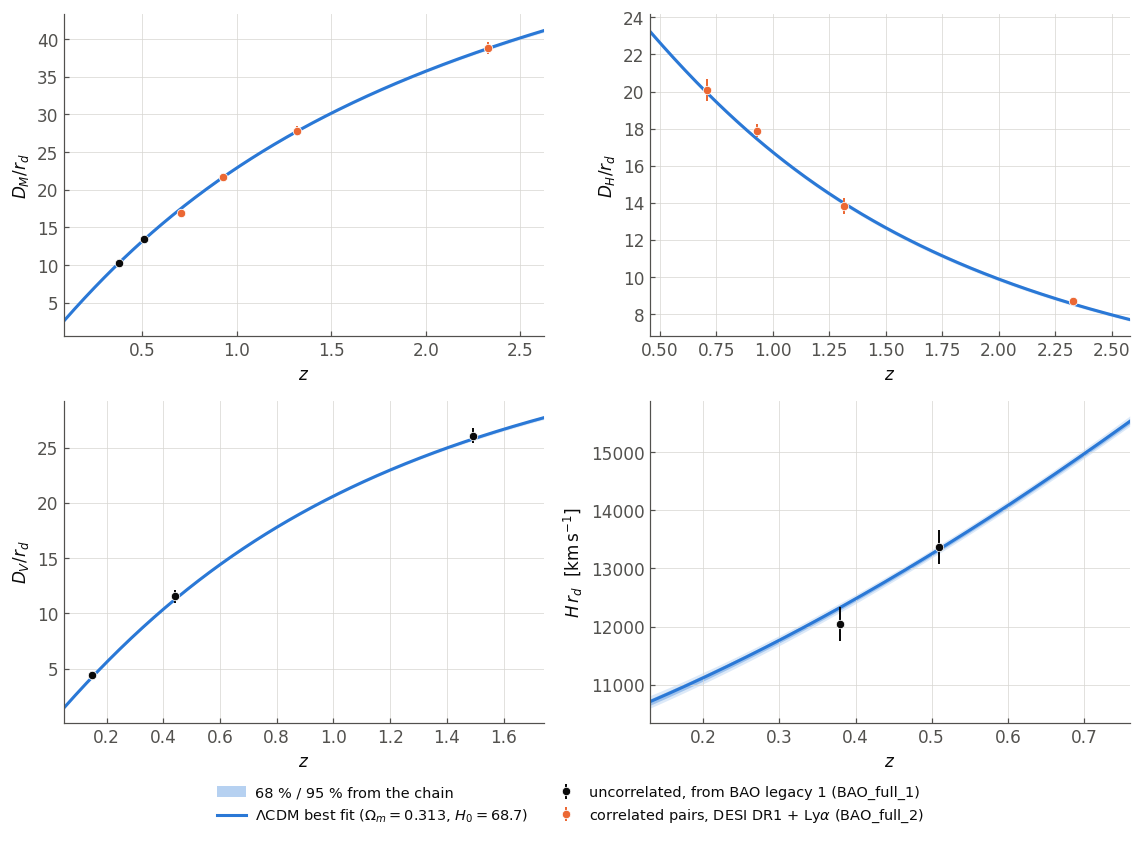

In [13]:
(bao_1, bao_2) = ds_BAO_full
z_b1, dist_b1, err2_b1, index_b1 = (np.asarray(a) for a in bao_1)
err_b1 = np.sqrt(err2_b1)
z_b2, dm_b2, edm_b2, dh_b2, edh_b2, rho_b2 = (np.asarray(a) for a in bao_2)

LAB_1 = 'uncorrelated, from BAO legacy 1 (BAO_full_1)'
LAB_2 = r'correlated pairs, DESI DR1 + Ly$\alpha$ (BAO_full_2)'

panels = [(2, r'$D_M/r_d$', z_b2, dm_b2, edm_b2),
          (1, r'$D_H/r_d$', z_b2, dh_b2, edh_b2),
          (3, r'$D_V/r_d$', None, None, None),
          (4, r'$H\,r_d\ \ [\rm km\,s^{-1}]$', None, None, None)]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))
for ax, (index, ylab, z2, y2, e2) in zip(axes.ravel(), panels):
    mask = index_b1 == index
    z_with_data = list(z_b1[mask]) + (list(z2) if z2 is not None else [])
    lo, hi = min(z_with_data), max(z_with_data)
    pad = max(0.15 * (hi - lo), 0.25)
    zgrid = np.linspace(max(lo - pad, 0.05), hi + pad, 300)

    best, q = tube(lambda m, z, i=index: m.bao(z, i), zgrid)
    plot_band(ax, zgrid, best, q, LAB_BF)
    if mask.any():
        plot_data(ax, z_b1[mask], dist_b1[mask], err_b1[mask], LAB_1, INK, ms=5.5, elw=1.3)
    if z2 is not None:
        plot_data(ax, z2, y2, e2, LAB_2, ALT, ms=5.5, elw=1.3)
    ax.set_xlabel('$z$')
    ax.set_ylabel(ylab)
    ax.set_xlim(zgrid[0], zgrid[-1])

fig.tight_layout()
legend_below(fig, axes, ncol=2)
fig.savefig(os.path.join(OUT, 'BAO_legacy_2.pdf'))
plt.show()

## 9. BAO legacy 1 (`BAO_legacy_1`)

The BAO dataset of the 2022 paper (`USE_BAO` in the config files, `dataset_BAO` in
`chi_square.py`): 20 measurements from SDSS DR7, WiggleZ, BOSS DR12, DES Y1, eBOSS and the
Ly$\alpha$ forests, **with no DESI point at all**. References in
`fr_mcmc/source/BAO_legacy_1/README.md`. The error bars are
$\sqrt{\sigma_{\rm stat}^2 + \sigma_{\rm syst}^2}$, as in `read_data_BAO`.

> **The $r_d$ in this figure is not the one the `dataset_BAO` branch computes.** Here it is the
> same CLASS $r_d$ used everywhere else in the notebook (146.08 Mpc). That branch instead
> overwrites it with `r_drag(omega_m, H_0, bao_param)`, where `bao_param` is the parameter whose
> prior in the config files is `[100, 200]` — that is, $r_d$ in Mpc — but `r_drag` receives it in
> place of $\omega_b$: with `bao_param = 147` it returns $r_d \approx 5$ Mpc. Only
> `config_LCDM_4p_PPS+CC+BAO.yml` has `USE_BAO: True` and `run_test_ext.py` does not offer this
> dataset, so it is dormant — but it has to be fixed before using it again.

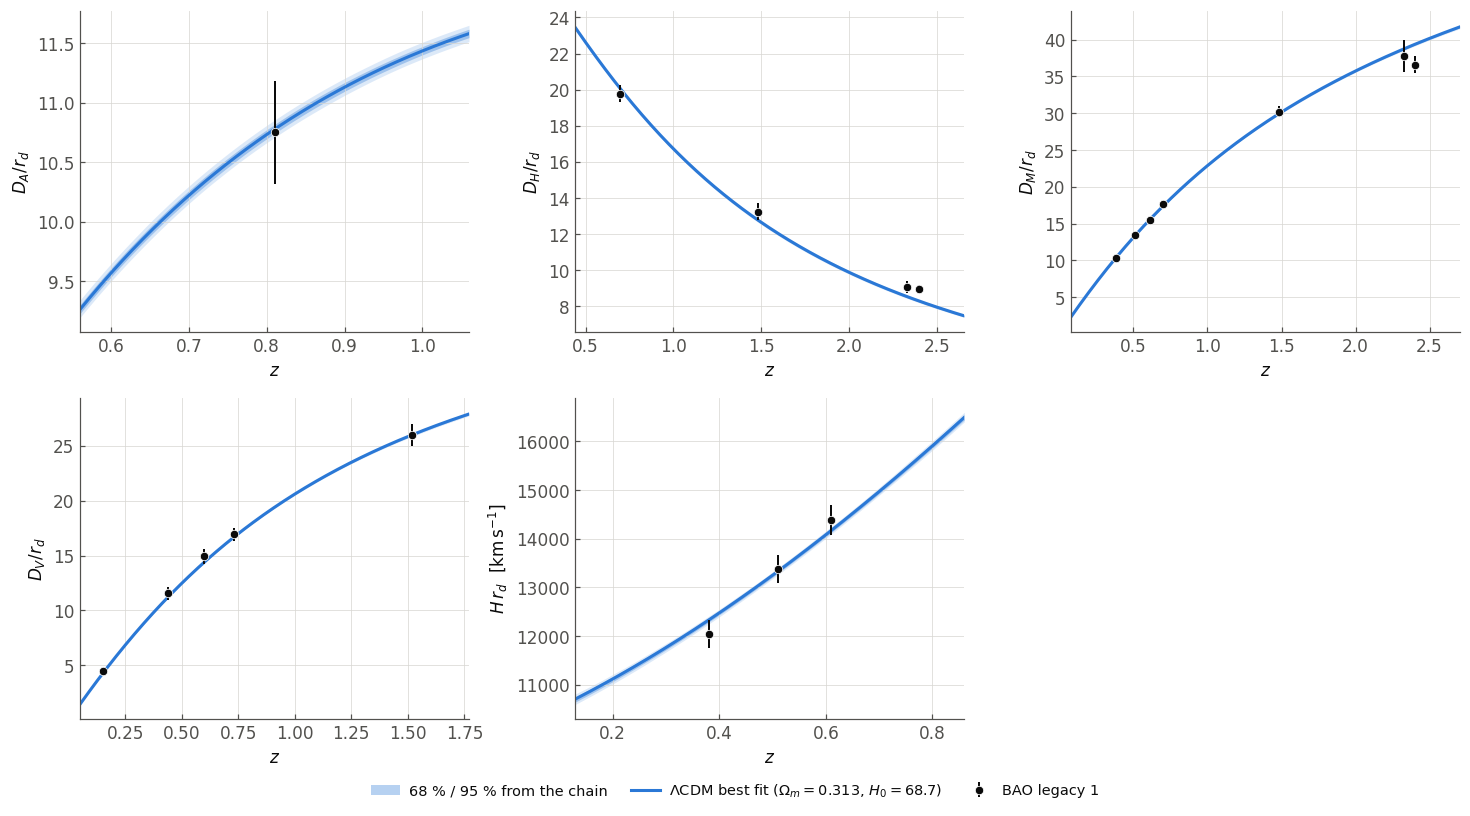

In [14]:
labels = [(0, r'$D_A/r_d$'), (1, r'$D_H/r_d$'), (2, r'$D_M/r_d$'),
          (3, r'$D_V/r_d$'), (4, r'$H\,r_d\ \ [\rm km\,s^{-1}]$')]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))
for ax, (index, ylab) in zip(axes.ravel(), labels):
    z_d, values, err2 = (np.asarray(a) for a in ds_BAO[index])
    pad = max(0.15 * (z_d.max() - z_d.min()), 0.25)
    zgrid = np.linspace(max(z_d.min() - pad, 0.05), z_d.max() + pad, 300)

    best, q = tube(lambda m, z, i=index: m.bao(z, i), zgrid)
    plot_band(ax, zgrid, best, q, LAB_BF)
    plot_data(ax, z_d, values, np.sqrt(err2), 'BAO legacy 1', INK, ms=5.5, elw=1.3)
    ax.set_xlabel('$z$')
    ax.set_ylabel(ylab)
    ax.set_xlim(zgrid[0], zgrid[-1])
axes.ravel()[-1].set_axis_off()

fig.tight_layout()
legend_below(fig, axes, ncol=3)
fig.savefig(os.path.join(OUT, 'BAO_legacy_1.pdf'))
plt.show()

## Extra: BAO legacy 2 and DESI DR2 in one figure

Normalising by $\sqrt{z}$ (the convention of the DESI figures) fits the three distance
observables in a single panel. $H\,r_d$ is left out because it is not a distance.

This is a **visual comparison, not a combination**: as noted in section 8, the two sets share
measurements and cannot be added in the same fit.

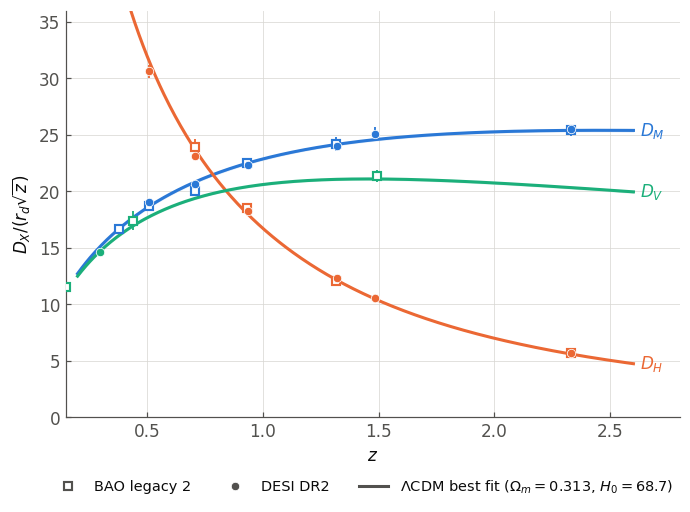

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
zgrid = np.linspace(0.2, 2.6, 400)   # below z ~ 0.2, D_H/(r_d sqrt(z)) diverges

for index, color, sym in [(2, MODEL, r'$D_M$'), (1, ALT, r'$D_H$'), (3, ALT2, r'$D_V$')]:
    best, q = tube(lambda m, z, i=index: m.bao(z, i) / np.sqrt(z), zgrid)
    ax.fill_between(zgrid, q[0], q[3], color=color, alpha=0.14, lw=0, zorder=1)
    ax.fill_between(zgrid, q[1], q[2], color=color, alpha=0.30, lw=0, zorder=1)
    ax.plot(zgrid, best, color=color, lw=2.0, zorder=2)
    ax.annotate(sym, xy=(zgrid[-1], best[-1]), xytext=(4, 0), textcoords='offset points',
                color=color, fontsize=11, va='center')

    mask = index_b1 == index
    if mask.any():
        ax.errorbar(z_b1[mask], dist_b1[mask] / np.sqrt(z_b1[mask]), err_b1[mask] / np.sqrt(z_b1[mask]),
                    fmt='s', ms=5, mfc='white', mec=color, mew=1.4, ecolor=color, elinewidth=1.2,
                    ls='none', zorder=3)
    if index == 2:
        ax.errorbar(z_b2, dm_b2 / np.sqrt(z_b2), edm_b2 / np.sqrt(z_b2), fmt='s', ms=5, mfc='white',
                    mec=color, mew=1.4, ecolor=color, elinewidth=1.2, ls='none', zorder=3)
        ax.errorbar(z_dmdh, dm_rd / np.sqrt(z_dmdh), edm_rd / np.sqrt(z_dmdh), fmt='o', ms=5.5,
                    mfc=color, mec='white', mew=0.5, ecolor=color, elinewidth=1.2, ls='none', zorder=4)
    if index == 1:
        ax.errorbar(z_b2, dh_b2 / np.sqrt(z_b2), edh_b2 / np.sqrt(z_b2), fmt='s', ms=5, mfc='white',
                    mec=color, mew=1.4, ecolor=color, elinewidth=1.2, ls='none', zorder=3)
        ax.errorbar(z_dmdh, dh_rd / np.sqrt(z_dmdh), edh_rd / np.sqrt(z_dmdh), fmt='o', ms=5.5,
                    mfc=color, mec='white', mew=0.5, ecolor=color, elinewidth=1.2, ls='none', zorder=4)
    if index == 3:
        ax.errorbar(z_dv, dv_rd / np.sqrt(z_dv), edv_rd / np.sqrt(z_dv), fmt='o', ms=5.5,
                    mfc=color, mec='white', mew=0.5, ecolor=color, elinewidth=1.2, ls='none', zorder=4)

markers = [Line2D([], [], ls='none', marker='s', ms=5, mfc='white', mec=INK2, mew=1.4, label='BAO legacy 2'),
           Line2D([], [], ls='none', marker='o', ms=5.5, mfc=INK2, mec='white', mew=0.5, label='DESI DR2'),
           Line2D([], [], color=INK2, lw=2.0, label=LAB_BF)]
ax.set_xlabel('$z$')
ax.set_ylabel(r'$D_X/(r_d\sqrt{z})$')
ax.set_xlim(0.15, 2.8)
ax.set_ylim(0, 36)
fig.legend(handles=markers, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)
fig.savefig(os.path.join(OUT, 'BAO_legacy_2_vs_DESI.pdf'))
plt.show()

In [16]:
print('Figures written to', OUT)
for f in sorted(os.listdir(OUT)):
    if f.endswith('.pdf'):
        print(' ', f)

Figures written to /home/matias/Documents/PhD/code/fR-MCMC/notebooks/output/plot_data_thesis
  AGN.pdf
  BAO_legacy_1.pdf
  BAO_legacy_2.pdf
  BAO_legacy_2_vs_DESI.pdf
  CC_cov.pdf
  CC_legacy.pdf
  DESI_DR2.pdf
  Pantheon.pdf
  Pantheon_plus.pdf
  QSO.pdf
